# Data Preprocessing 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram,linkage

In [3]:
data=pd.read_csv(r"C:\Users\User\Downloads\spotify.csv")


In [4]:
pd.set_option('display.max_columns', None)  # Show all columns
data.head()


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [6]:
data = data.drop(columns='Unnamed: 0')
data.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [7]:
data.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [8]:
data.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [9]:
data.dropna(inplace=True)

In [10]:
#checking for nulls in the data
data.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [11]:
data.shape

(113999, 20)

In [12]:
# Checking the duplicates in the data
data.duplicated().sum()

450

In [13]:
data.drop_duplicates(inplace=True)

In [14]:
data.shape

(113549, 20)

In [15]:
non_numeric = ['track_id', 'track_name', 'artists', 'album_name', 'track_genre']
data1 = data.drop(columns=non_numeric)
# df.drop((df.select_dtypes(include='object').columns),axis=1)

In [16]:
data1.shape

(113549, 15)

In [17]:
#Binary mapping the boolean column in the data, 
data1['explicit'] = data1['explicit'].astype(int)

In [18]:
data1.head(30)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
5,58,214240,0,0.688,0.4810,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4
6,74,229400,0,0.407,0.1470,2,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3
7,80,242946,0,0.703,0.4440,11,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4
8,74,189613,0,0.625,0.4140,0,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4
9,56,205594,0,0.442,0.6320,1,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4


# Exploratory Data Analysis

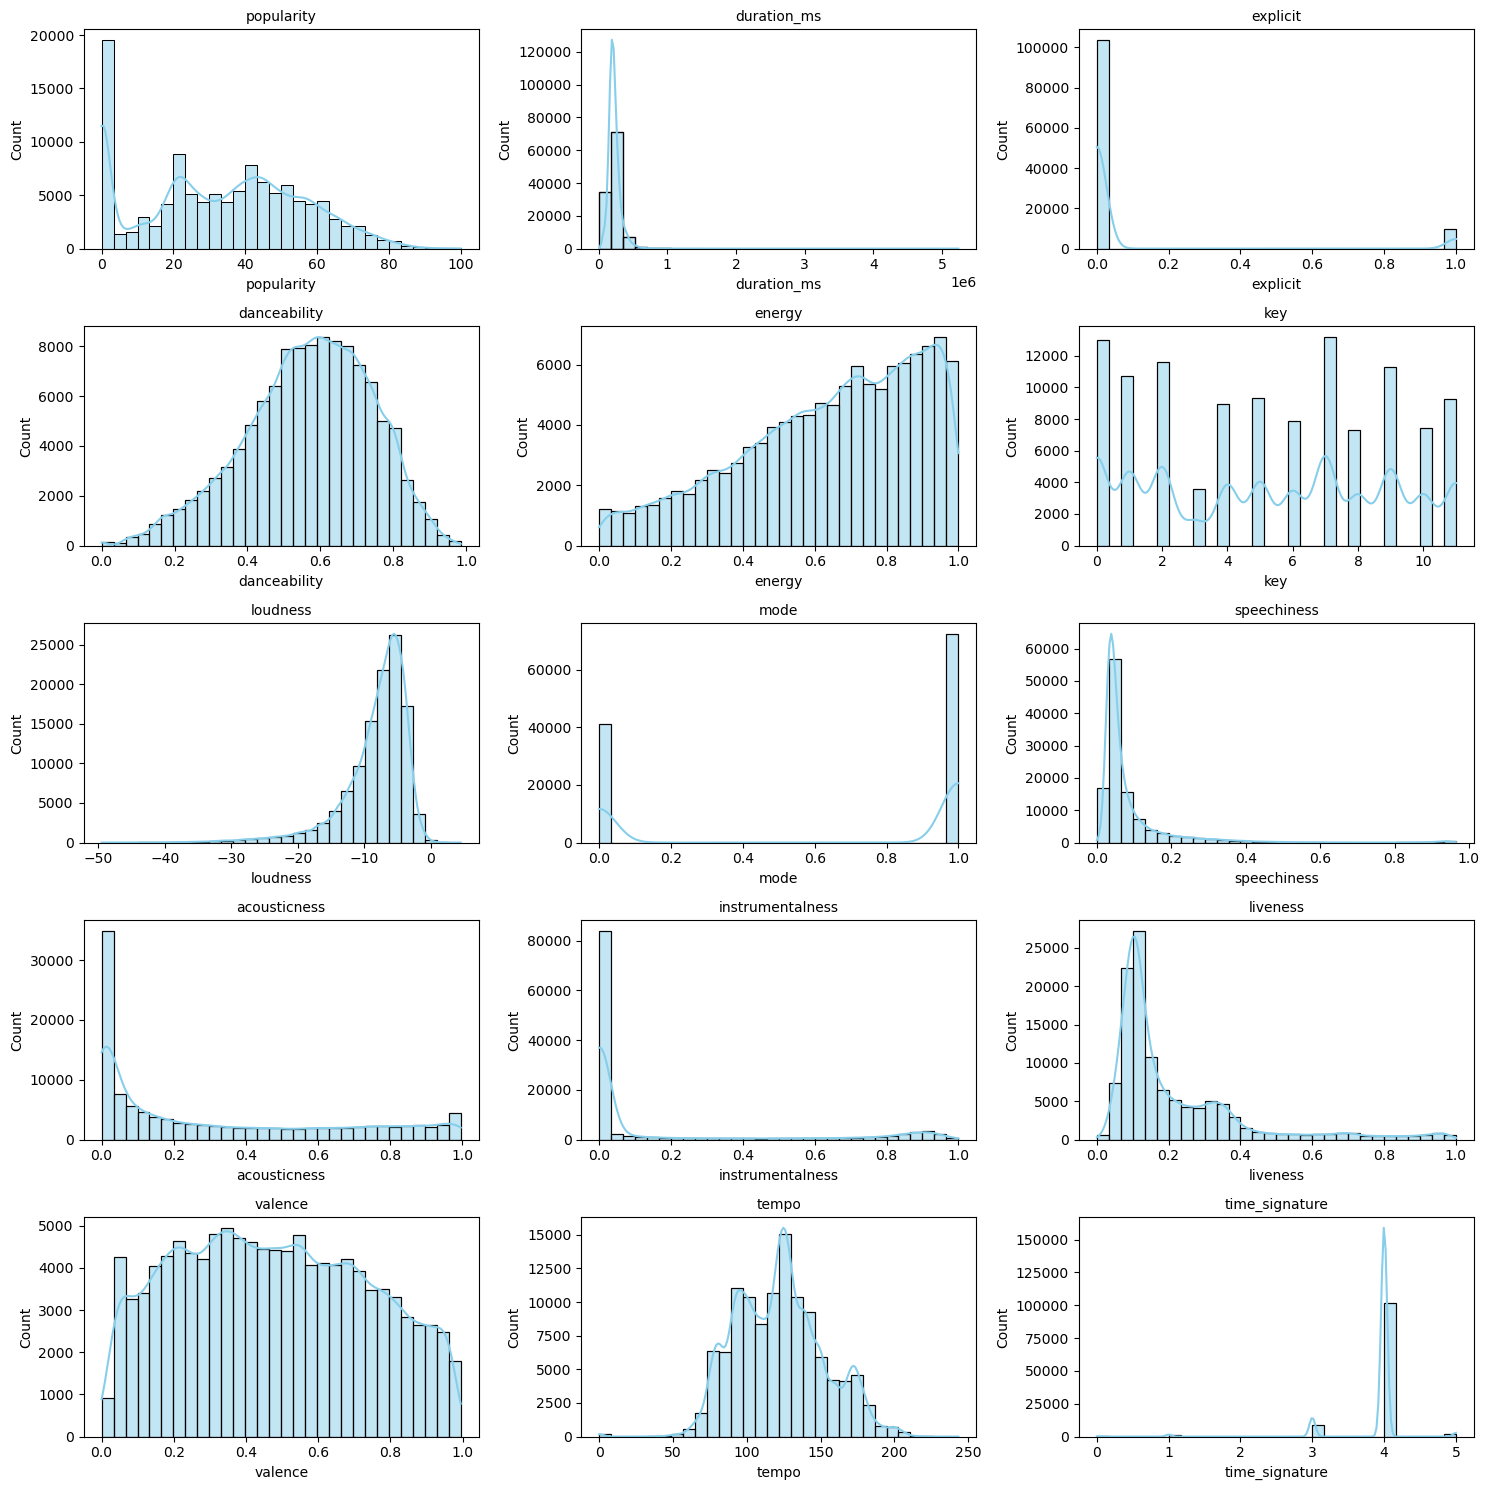

In [20]:
# Set number of columns
cols = 3
numeric_features = data1.columns.tolist()
total = len(numeric_features)
rows = (total + cols - 1) // cols  # ceil-like logic without importing math

# Set figure size
plt.figure(figsize=(cols * 5, rows * 3))

# Loop through and create subplots
for i, col in enumerate(numeric_features):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(data[col], kde=True, bins=30, color='skyblue')
    plt.title(col, fontsize=10)
    plt.tight_layout()

plt.show()

In [21]:
#optional
# numeric_cols = data.select_dtypes(include=['number']).columns  # safer than using all columns

# plt.figure(figsize=(16, 12))

# for i, col in enumerate(numeric_cols):
#     plt.subplot(4, 4, i + 1)
#     sns.histplot(data[col], kde=True, bins=30, color='steelblue')
#     plt.title(col)

# plt.tight_layout()
# plt.show()


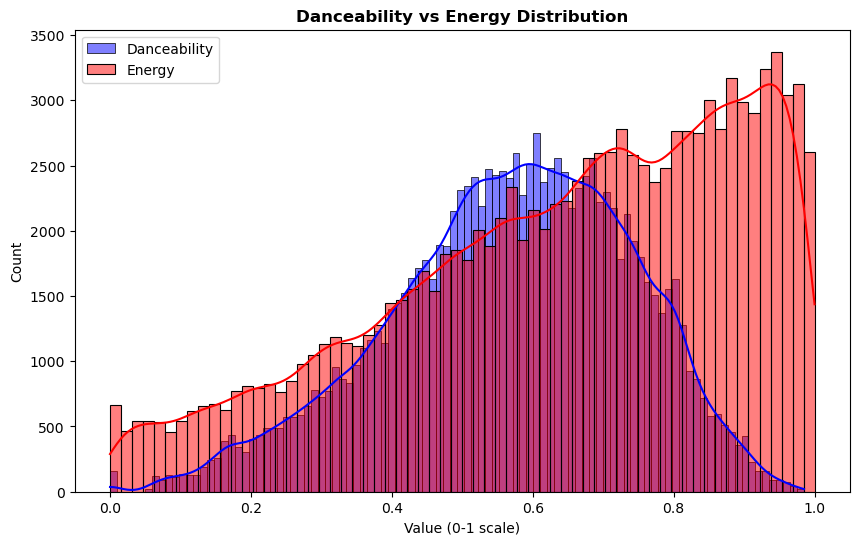

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(data=data1, x='danceability', color='Blue', alpha=0.5, label='Danceability', kde=True)
sns.histplot(data=data1, x='energy', color='Red', alpha=0.5, label='Energy', kde=True)
plt.title('Danceability vs Energy Distribution', fontweight='bold')
plt.xlabel('Value (0-1 scale)')
plt.legend()
plt.savefig("Danceability vs Energy Distribution.png")
plt.show()

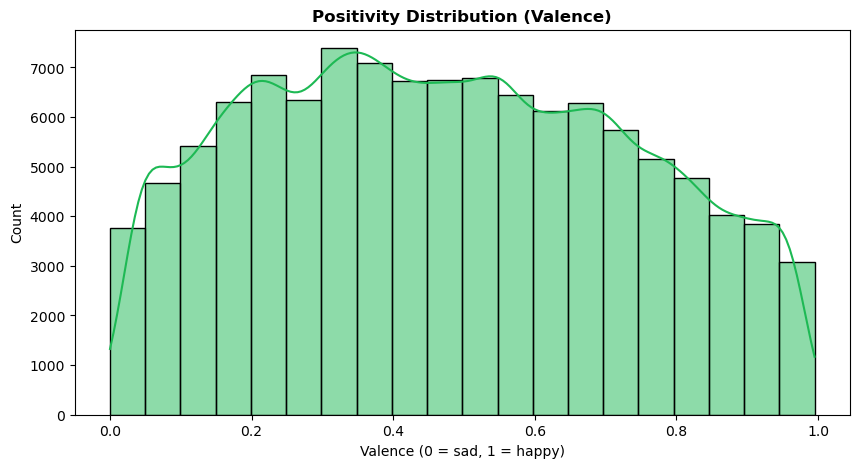

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(data=data1, x='valence', bins=20, color='#1DB954', kde=True)
plt.title('Positivity Distribution (Valence)', fontweight='bold')
plt.xlabel('Valence (0 = sad, 1 = happy)')
plt.savefig("positivity Valence.png")
plt.show()

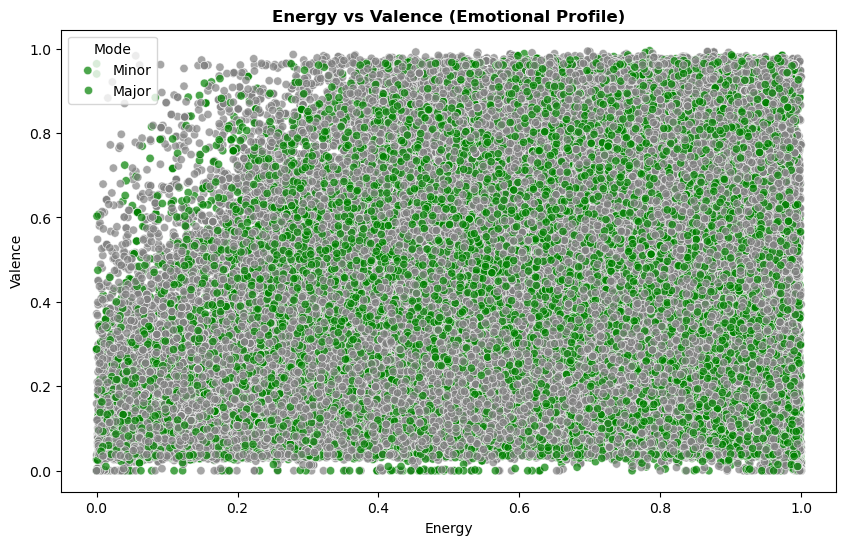

In [24]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data1, x='energy', y='valence', hue='mode', 
                palette={0: 'Green', 1: 'Grey'}, alpha=0.7)
plt.title('Energy vs Valence (Emotional Profile)', fontweight='bold')
plt.xlabel('Energy')
plt.ylabel('Valence')
plt.legend(title='Mode', labels=['Minor', 'Major'])
plt.savefig("Energy vs Valence.png")
plt.show()

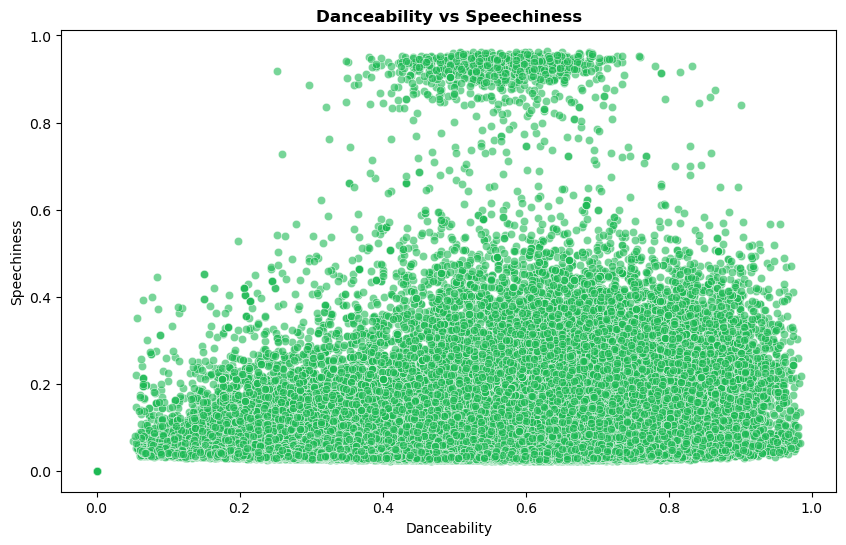

In [25]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data1, x='danceability', y='speechiness', 
                color='#1DB954', alpha=0.6)
plt.title('Danceability vs Speechiness', fontweight='bold')
plt.xlabel('Danceability')
plt.ylabel('Speechiness')
plt.show()

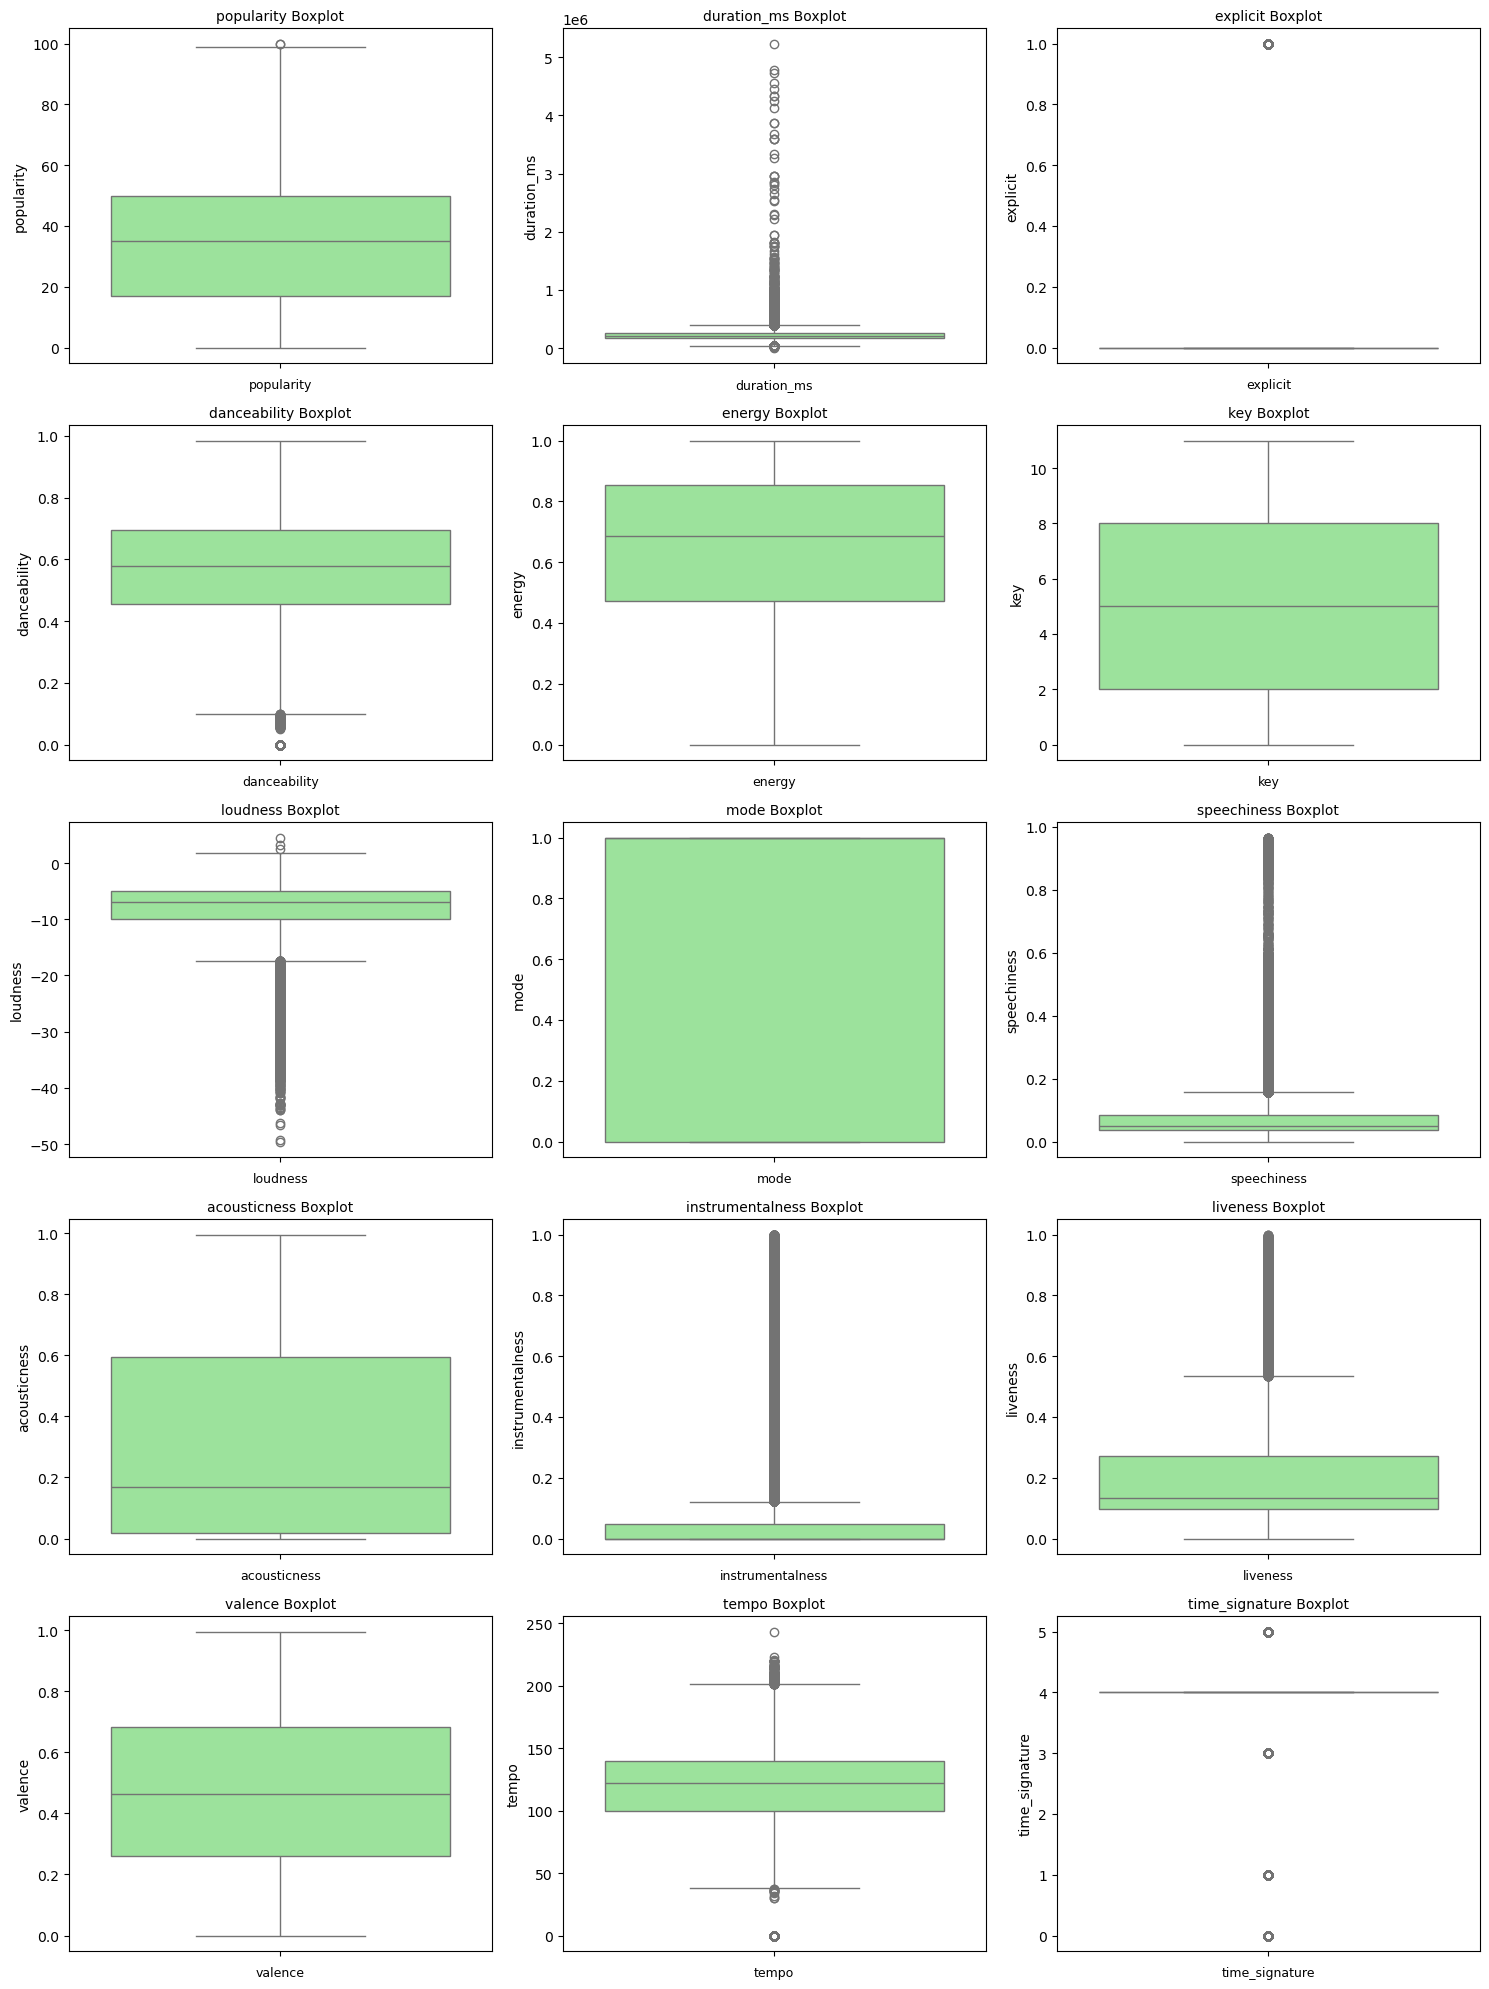

In [26]:
# Define layout
cols = 3
numeric_features = data1.columns.tolist()
total = len(numeric_features)
rows = (total + cols - 1) // cols  # Ceiling division

# Set figure size
plt.figure(figsize=(cols * 5, rows * 4))

# Loop and plot
for i, col in enumerate(numeric_features):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(data=data1, y=col, color='lightgreen')
    plt.title(f'{col} Boxplot', fontsize=10)
    plt.xlabel(col, fontsize=9)
    plt.tight_layout()

plt.show()

In [27]:
data1.shape

(113549, 15)

In [28]:
features_to_clean = ['duration_ms', 'loudness', 'speechiness', 'tempo', 'time_signature']

df2 = data1.copy()  # Start with the original data
for col in features_to_clean:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1

    Lowerbound = Q1 - 1.5 * IQR
    Upperbound = Q3 + 1.5 * IQR

    df2 = df2[(df2[col] >= Lowerbound) & (df2[col] <= Upperbound)]

df2.shape


(82448, 15)

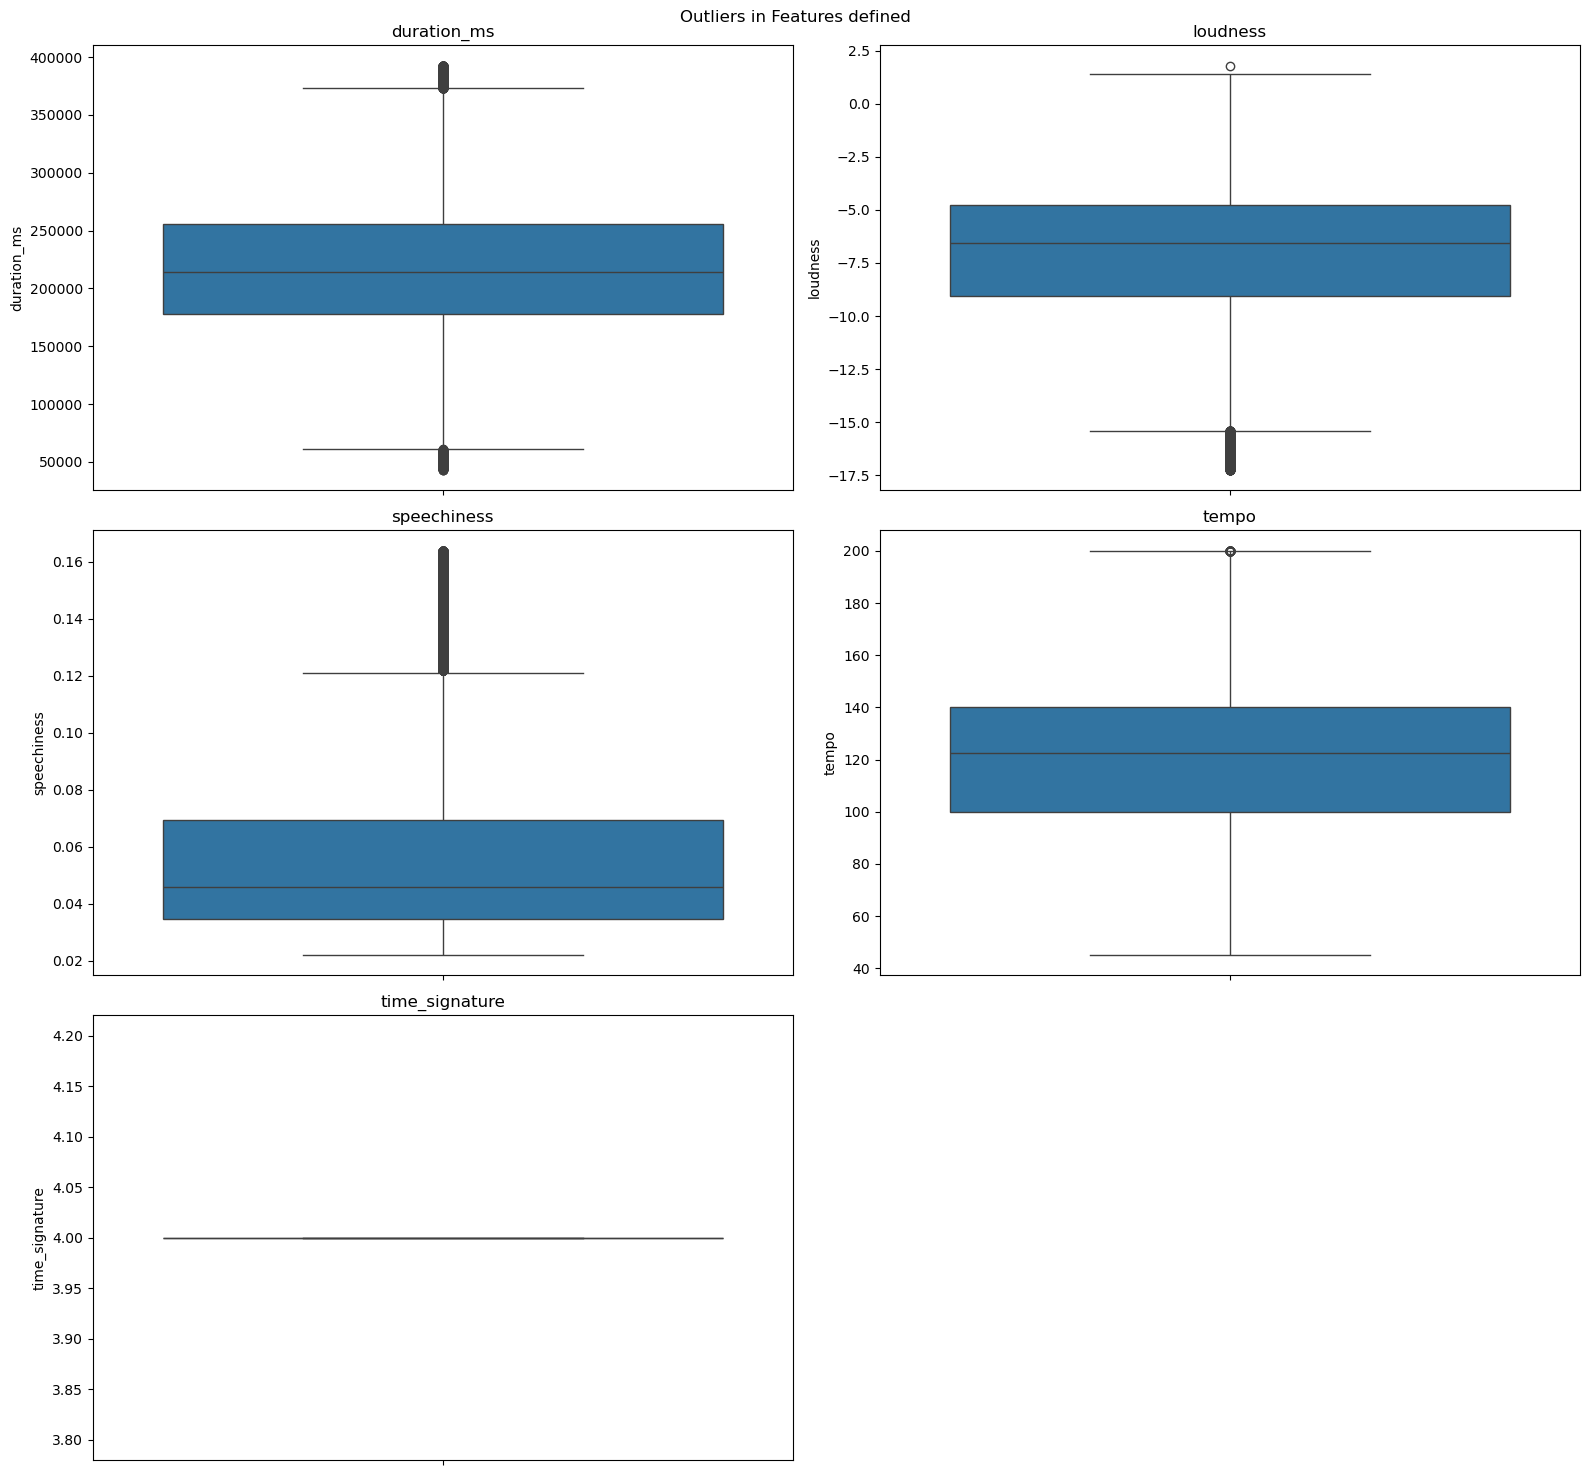

In [29]:
plt.figure(figsize=(16,15))
plt.suptitle("Outliers in Features defined")
for i ,col in enumerate(features_to_clean):
    plt.subplot(3,2,i+1)
    sns.boxplot(data=df2, y=col)
    plt.title(col)

plt.tight_layout()
plt.savefig('Outlier Removed Spotify.png')
plt.show()

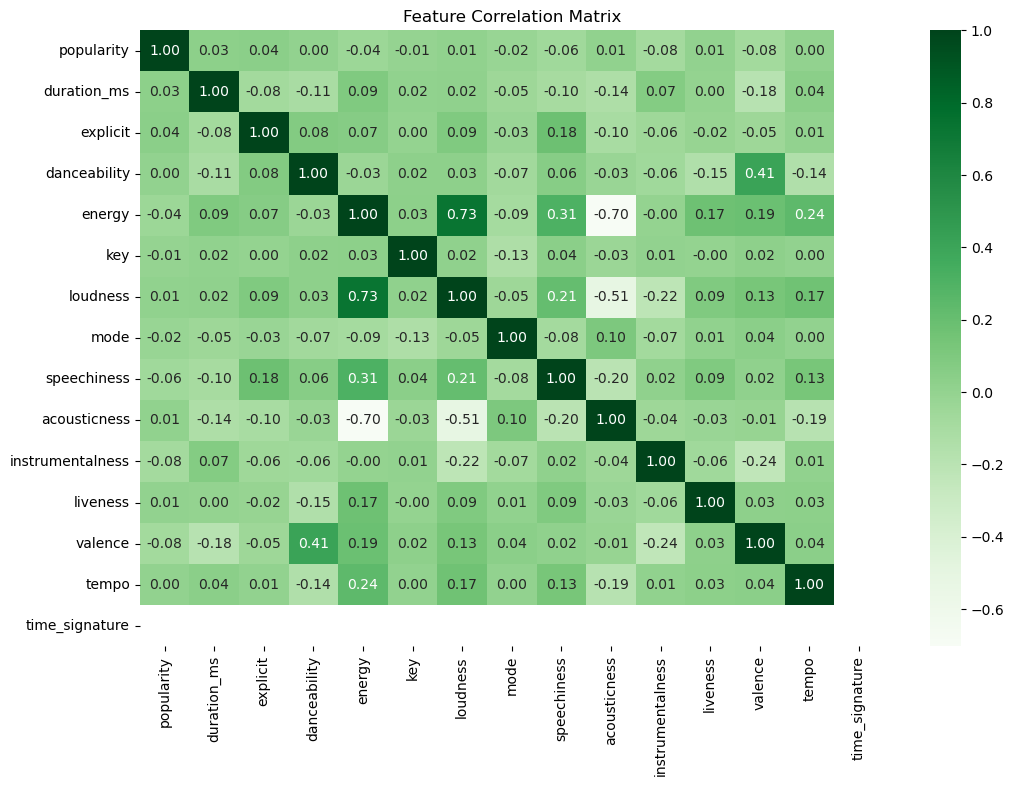

In [30]:
plt.figure(figsize=(12, 8))
sns.heatmap(df2.corr(), annot=True, fmt=".2f", cmap="Greens")
plt.title("Feature Correlation Matrix")
plt.savefig("Heatmap Spotify.png")
plt.show()

In [31]:
# Scale numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df2)

In [32]:
from sklearn.decomposition import PCA
# Fit PCA
pca = PCA(n_components=2)  
pca_features = pca.fit_transform(scaled_data)

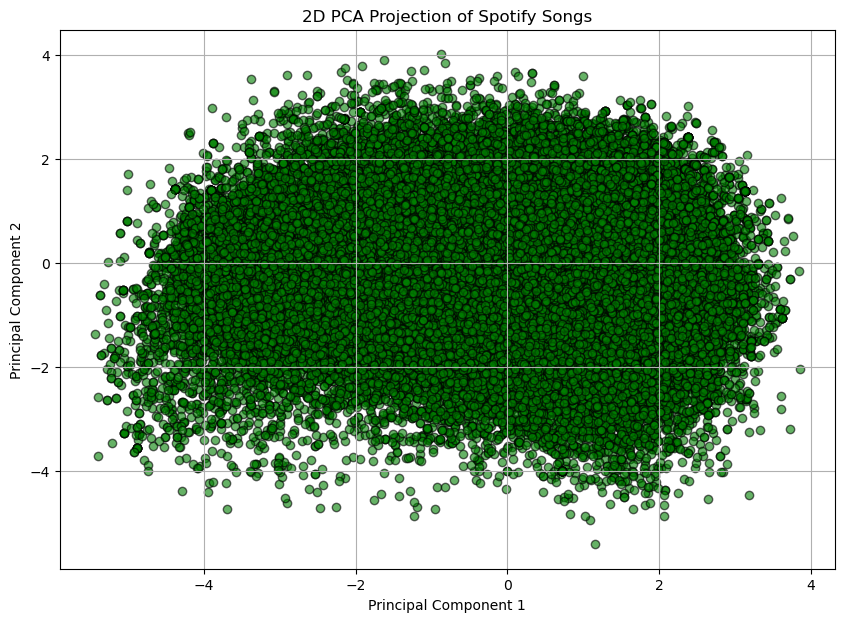

In [33]:
plt.figure(figsize=(10, 7))
plt.scatter(pca_features[:, 0], 
    pca_features[:, 1], 
    alpha=0.6, 
    c='Green', 
    edgecolor='k'
)
plt.title('2D PCA Projection of Spotify Songs')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [34]:
pca1=PCA()
pca_data=pca1.fit_transform(scaled_data)

In [35]:
# Explained variance
explained = np.cumsum(pca1.explained_variance_ratio_)
explained

array([0.1869513 , 0.30314722, 0.39194957, 0.47369797, 0.55220203,
       0.6271379 , 0.69437131, 0.75790627, 0.81595131, 0.87329636,
       0.92452573, 0.95901187, 0.98877159, 1.        , 1.        ])

To explain 90% of the variance, you need at least 11 components.

To explain 95%, you need 12 components.

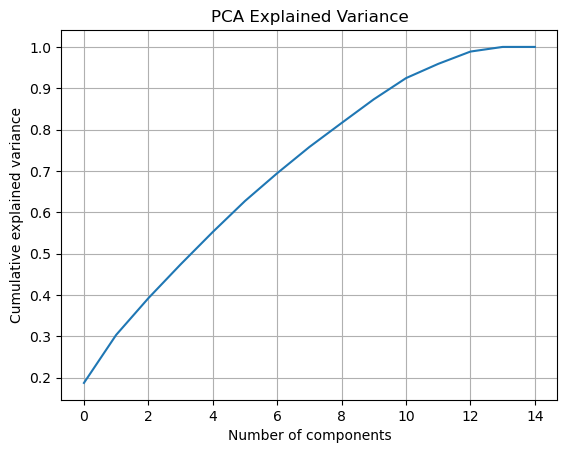

In [110]:
plt.plot(explained)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.savefig("PCA Explained Variance.png")
plt.show()

In [38]:
# Fit PCA
pca2= PCA(n_components=2)  
pca_features_2 = pca2.fit_transform(scaled_data)

In [39]:
interias = []
sil_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_features_2)
    labels = kmeans.labels_

    # Use a sample of 1000 to compute silhouette score
    sil_score_k = silhouette_score(pca_features_2, labels, random_state=42)
    sil_scores.append(sil_score_k)

    inertia_k = kmeans.inertia_
    interias.append(inertia_k)

    print(f"K={k}: Silhouette Score = {sil_score_k:.2f}, Inertia = {inertia_k:.2f}")


K=2: Silhouette Score = 0.40, Inertia = 201479.05
K=3: Silhouette Score = 0.38, Inertia = 134365.79
K=4: Silhouette Score = 0.34, Inertia = 107544.33
K=5: Silhouette Score = 0.35, Inertia = 88096.94
K=6: Silhouette Score = 0.34, Inertia = 75029.01
K=7: Silhouette Score = 0.33, Inertia = 65992.23
K=8: Silhouette Score = 0.32, Inertia = 60065.03
K=9: Silhouette Score = 0.33, Inertia = 52560.94
K=10: Silhouette Score = 0.33, Inertia = 47833.40


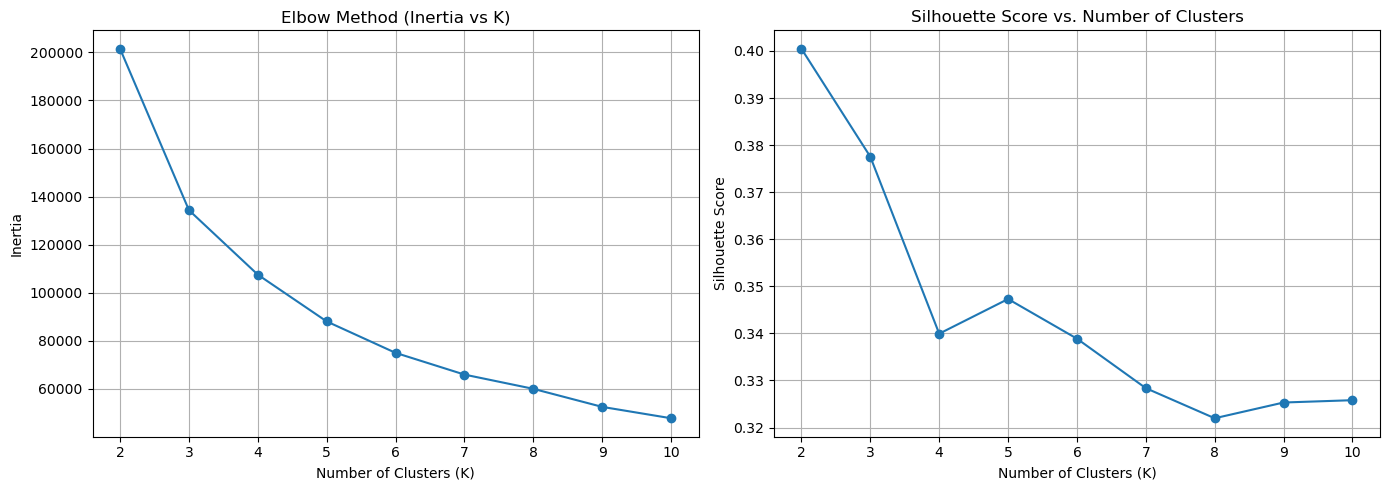

In [112]:
import matplotlib.pyplot as plt

k_values = range(2, 11)

plt.figure(figsize=(14, 5))

# Subplot 1: Elbow Curve
plt.subplot(1, 2, 1)
plt.plot(k_values, interias, marker='o', linestyle='-')
plt.title('Elbow Method (Inertia vs K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)

# Subplot 2: Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_values, sil_scores, marker='o', linestyle='-')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.savefig("Elbow method vs Silhouette score.png")
plt.show()


K=3 strikes a balance between the silhouette score and inertia since at k=3 that;s the rate at which the decrease starts to slow down between k=3 and k-4 and also at k= 3 the silhouette score is higher, but considering the elbow curve it starts to show the decrease when value of k =3 and 4 :Still interpretable.Better granularity than K=2.Good silhouette score — so clusters are not overlapping too

In [42]:
# Step 2: KMeans clustering
model = KMeans(n_clusters=3, random_state=42)
model.fit(pca_features_2)
model_labels = model.labels_

# Step 3: Evaluate clustering
sil_score = silhouette_score(pca_features_2, model_labels, random_state=42)
db_score = davies_bouldin_score(pca_features_2, model_labels)

print(f"Silhouette Score (PCA 2 components, sample=1000): {sil_score:.2f}")
print(f"Davies-Bouldin Score (PCA 2 components): {db_score:.2f}")



Silhouette Score (PCA 2 components, sample=1000): 0.38
Davies-Bouldin Score (PCA 2 components): 0.90


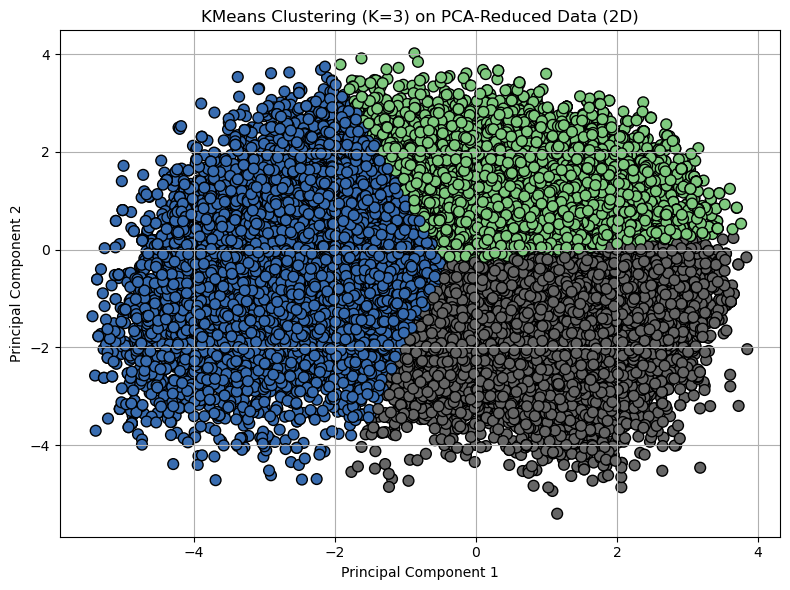

In [114]:
# Step 4: Plotting Clusters
plt.figure(figsize=(8, 6))
plt.scatter(pca_features_2[:, 0], pca_features_2[:, 1], c=model_labels, cmap='Accent', s=60, edgecolor='k')
plt.title('KMeans Clustering (K=3) on PCA-Reduced Data (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.savefig("kmeans clustering.png")
plt.show()

In [44]:
## Kmeans 
kmodel=KMeans(n_clusters=3,random_state=42)
kmodel.fit(pca_features_2)
label=kmodel.labels_
unique_labels = np.unique(label)
print("Unique cluster labels:", unique_labels)

import collections

label_counts = collections.Counter(label)
print("Cluster counts:", label_counts)

Unique cluster labels: [0 1 2]
Cluster counts: Counter({0: 34113, 2: 25419, 1: 22916})


In [45]:
df2['cluster']=model_labels
df2.head(24)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,cluster
0,73,230666,0,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,0
1,55,149610,0,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,1
2,57,210826,0,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,1
4,82,198853,0,0.618,0.443,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,1
5,58,214240,0,0.688,0.481,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.666,98.017,4,0
7,80,242946,0,0.703,0.444,11,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.712,150.960,4,1
8,74,189613,0,0.625,0.414,0,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.669,130.088,4,1
9,56,205594,0,0.442,0.632,1,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.196,78.899,4,1
10,74,244800,0,0.627,0.363,8,-8.127,1,0.0291,0.2790,0.000000,0.0928,0.301,99.905,4,1
12,52,198712,0,0.489,0.314,7,-9.245,0,0.0331,0.7490,0.000000,0.1130,0.607,124.234,4,1


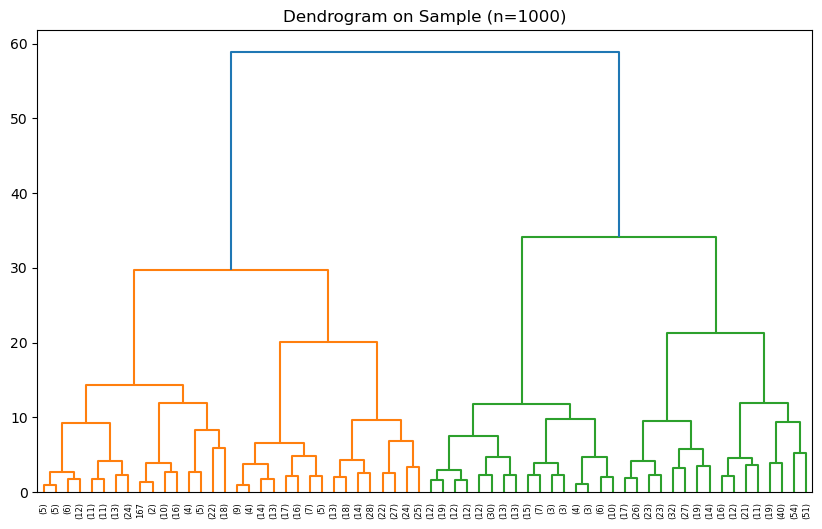

In [116]:

# Sample 1000 rows randomly from your data
df_sample = pca_features_2[np.random.choice(pca_features_2.shape[0], 1000, replace=False)]

# Then run linkage and dendrogram on the sample
linked = linkage(df_sample, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Dendrogram on Sample (n=1000)")
plt.savefig("Dendrogram spotify.png")
plt.show()

In [47]:
#Set number of clusters based on dendrogram
n_clusters = 3  # Adjust based on dendrogram

# Fit model
agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
agg_labels = agg.fit_predict(df_sample)

# Evaluate clustering
sil_agg = silhouette_score(df_sample, agg_labels)
db_agg = davies_bouldin_score(df_sample, agg_labels)

print(f"Agglomerative Clustering (n_clusters={n_clusters})")
print(f"Silhouette Score = {sil_agg:.3f}")
print(f"Davies-Bouldin Score = {db_agg:.3f}")


Agglomerative Clustering (n_clusters=3)
Silhouette Score = 0.326
Davies-Bouldin Score = 0.947


In [122]:
pca_features_2 = pd.DataFrame(pca_features_2, columns=[f'PC{i+1}' for i in range(pca_features_2.shape[1])])

pca_features_2['cluster'] = kmeans.labels_

label_map = {
    0: "Chill Pop / Acoustic Groove",
    1: "Mainstream Dance / EDM-Pop",
    2: "Stripped Down / Acoustic Ballads"
}
pca_features_2['cluster_label'] = pca_features_2['cluster'].map(label_map)

pca_features_2 = pca_features_2.reset_index(drop=True)
data = data.reset_index(drop=True)

pca_features_2[['track_name', 'artists']] = data[['track_name', 'artists']]



In [ ]:
print("Unique clusters:", pca_features_2['cluster'].unique())
print("NaNs in cluster_label:", pca_features_2['cluster_label'].isnull().sum())


In [124]:
recommendations = df2.groupby('cluster_label', group_keys=False).apply(
    lambda x: x.sample(n=min(3, len(x)), random_state=42)
)[['track_name', 'artists', 'cluster_label']]

recommendations.reset_index(drop=True, inplace=True)
recommendations



C:\Users\User\AppData\Local\Temp\ipykernel_28432\1074925969.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  recommendations = df2.groupby('cluster_label', group_keys=False).apply(


,track_name,artists,cluster_label
0,Tuffa tider (För en drömmare),Gyllene Tider,Chill Pop / Acoustic Groove
1,Fade Out Lines,The Avener,Chill Pop / Acoustic Groove
2,O Papa é Pop,Engenheiros Do Hawaii,Chill Pop / Acoustic Groove
3,Remember That Night?,Sara Kays,Mainstream Dance / EDM-Pop
4,All Night (Live),AP Dhillon;Shinda Kahlon,Mainstream Dance / EDM-Pop
5,Tempo de Cantar,Fabiana Sinfrônio,Mainstream Dance / EDM-Pop
6,La Milonga de Mis Tiempos,Francisco Canaro,Stripped Down / Acoustic Ballads
7,Hills,AP Dhillon,Stripped Down / Acoustic Ballads
8,Speaking Sonar,Summer Salt,Stripped Down / Acoustic Ballads


In [50]:
seeds = [10, 42, 50, 77 ]

# Store scores for comparison  results:
results = []

for seed in seeds:
    kmeans = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(pca_features_2)  # use scaled data, not PCA
    
    sil_score = silhouette_score(pca_features_2, labels)
    db_score = davies_bouldin_score(pca_features_2, labels)
    
    results.append((seed, sil_score, db_score))
    print(f"Seed={seed} → Sil_Score = {sil_score:.3f}, Davies-Bouldin= {db_score:.3f}")


Seed=10 → Sil_Score = 0.377, Davies-Bouldin= 0.900
Seed=42 → Sil_Score = 0.377, Davies-Bouldin= 0.899
Seed=50 → Sil_Score = 0.377, Davies-Bouldin= 0.900
Seed=77 → Sil_Score = 0.377, Davies-Bouldin= 0.900


In [51]:
df2.groupby('cluster_label').mean(numeric_only=True)

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,cluster
cluster_label,,,,,,,,,,,,,,,,
Chill Pop / Acoustic Groove,35.850340,214918.219518,0.069939,0.646286,0.732660,5.231080,-6.387910,0.627668,0.052383,0.179016,0.041377,0.210101,0.595227,120.307917,4.0,0.0
Mainstream Dance / EDM-Pop,38.291129,228514.038217,0.024561,0.573613,0.522736,5.162609,-8.777055,0.698179,0.043055,0.428472,0.094506,0.189334,0.421141,115.345651,4.0,1.0
Stripped Down / Acoustic Ballads,32.067808,177931.241736,0.017800,0.620303,0.331096,4.882014,-11.615046,0.800644,0.044672,0.756847,0.074813,0.156594,0.526067,106.759012,4.0,2.0


In [52]:
def predict_cluster(new_song, scaler, pca, model, label_map):
    
    scaled = scaler.transform([new_song])
    reduced = pca.transform(scaled)
    cluster = model.predict(reduced)[0]
    label = label_map.get(cluster, f"Unknown Cluster {cluster}")
    return cluster, label


In [53]:
# Sample song features (must match order and length of training features)
w = [0.6, 0.7, 5.0, -8.0, 1.0, 0.04, 0.2, 0.0, 0.1, 0.4, 120.0, 4.0,0.01,0.2,0.0]

# Call function
cluster_num, cluster_label = predict_cluster(w, scaler, pca, kmeans, label_map)

# Print result
print(f"Cluster Number: {cluster_num}, Label: {cluster_label}")


Cluster Number: 0, Label: Chill Pop / Acoustic Groove


C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [54]:
print(pca.components_.shape) 

(2, 15)


In [126]:
pca_features_2.head(40)

,PC1,PC2,cluster,cluster_label,track_name,artists
0,0.643450,0.920321,1,Mainstream Dance / EDM-Pop,Comedy,Gen Hoshino
1,-4.566814,0.017494,2,Stripped Down / Acoustic Ballads,Ghost - Acoustic,Ben Woodward
2,-1.960297,-0.907486,2,Stripped Down / Acoustic Ballads,To Begin Again,Ingrid Michaelson;ZAYN
3,-1.811459,-0.271599,2,Stripped Down / Acoustic Ballads,Can't Help Falling In Love,Kina Grannis
4,-0.558760,1.169377,1,Mainstream Dance / EDM-Pop,Hold On,Chord Overstreet
5,-1.298747,0.905165,2,Stripped Down / Acoustic Ballads,Days I Will Remember,Tyrone Wells
6,-1.233675,0.826611,2,Stripped Down / Acoustic Ballads,Say Something,A Great Big World;Christina Aguilera
7,-1.330695,-0.639945,2,Stripped Down / Acoustic Ballads,I'm Yours,Jason Mraz
8,-1.640431,-0.120702,2,Stripped Down / Acoustic Ballads,Lucky,Jason Mraz;Colbie Caillat
9,-2.170446,0.334183,2,Stripped Down / Acoustic Ballads,Hunger,Ross Copperman


In [128]:
import joblib

#saving the model
joblib.dump(kmeans, 'kmeans_cluster_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')

['pca.pkl']